# CleanTest-Agent · Filter 3 模型训练实验记录

- 任务：在 LessIsMore-FSE2025 (469K 行 Methods2Test) 上微调 `Qwen/Qwen2.5-Coder-0.5B`，作为 CleanTest Filter 3 的覆盖率回归器。
- 硬件：百度飞桨 AI Studio · NVIDIA A800 80GB。
- 框架：PaddlePaddle 3.0 + PaddleNLP 3.0.0b3 + Python 3.10。

---
## 1 环境准备

In [1]:
# Cell 3 [Python] sys.path 净化 + paddle / GPU 自检

import os, sys

try:
    os.getcwd()
except FileNotFoundError:
    os.chdir("/home/aistudio"); print("cwd reset to:", os.getcwd())

sys.path = [p for p in sys.path if "external-libraries" not in p]

import paddle
print("Python        :", sys.version.split()[0])
print("sys.executable:", sys.executable)
print("paddle ver    :", paddle.__version__)
print("CUDA ok       :", paddle.device.is_compiled_with_cuda())
if paddle.device.is_compiled_with_cuda():
    name  = paddle.device.cuda.get_device_name(0)
    props = paddle.device.cuda.get_device_properties(0)
    print("Device        :", name)
    print("Memory GB     :", round(props.total_memory / 1024**3, 1))
    bf16_capable = any(k in name.lower() for k in ["a800", "a100", "h100", "h800"])
    print("bf16 capable  :", bf16_capable)
    assert bf16_capable, "GPU does not natively support bf16; switch instance to A800/A100/H100."

/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Python        : 3.10.10
sys.executable: /opt/conda/envs/pure-paddle/bin/python
paddle ver    : 3.3.0
CUDA ok       : True
Device        : NVIDIA A800-SXM4-80GB
Memory GB     : 79.3
bf16 capable  : True


In [2]:
# Cell 4 [Python] 一次性安装 paddlenlp 3.0 + 周边依赖（首次启动 kernel 后跑一次）

import os, sys, subprocess

try:
    os.getcwd()
except FileNotFoundError:
    os.chdir("/home/aistudio")

py = sys.executable
env = os.environ.copy()
env["PIP_USER"] = "0"
MIRROR = "https://pypi.tuna.tsinghua.edu.cn/simple"

def pip_install(*pkgs):
    subprocess.check_call(
        [py, "-m", "pip", "install", "-U", *pkgs, "-i", MIRROR],
        env=env, cwd="/home/aistudio",
    )

pip_install("aistudio_sdk==0.2.5")
pip_install("paddlenlp>=3.0.0b3")
pip_install(
    "jieba", "seqeval", "datasets",
    "scipy>=1.10", "scikit-learn>=1.3",
    "sentencepiece", "safetensors",
    "huggingface_hub>=0.20", "modelscope>=1.30",
    "pandas>=1.5", "matplotlib>=3.7",
)

print("\nAll deps installed.")
print("==> NEXT: please RESTART KERNEL (Menu -> Kernel -> Restart),")
print("         then continue from Cell 5.")

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.9 kB/s  0:00:35 eta 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [aistudio_sdk] [bce-python-sdk]zer]
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 3.1 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 9.6 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished w

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tokenizers 0.21.4 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.16.1 which is incompatible.


In [4]:
import sys, subprocess, os

py = sys.executable
env = os.environ.copy()
env["PIP_USER"] = "0"
MIRROR = "https://pypi.tuna.tsinghua.edu.cn/simple"

subprocess.check_call(
    [py, "-m", "pip", "install",
     "numpy>=1.26,<2.0",
     "scipy>=1.10,<1.13",
     "-i", MIRROR],
    env=env, cwd="/home/aistudio",
)

print("\n==> RESTART KERNEL now, then re-run Cell 5 (skip Cell 4).")


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 254.0 kB/s  0:01:500:00:0100:05
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3

==> RESTART KERNEL now, then re-run Cell 5 (skip Cell 4).


In [5]:
import sys, subprocess, os
py = sys.executable
env = os.environ.copy()
env["PIP_USER"] = "0"
subprocess.check_call(
    [py, "-m", "pip", "install", "paddlenlp>=3.0.0b3",
     "-i", "https://pypi.tuna.tsinghua.edu.cn/simple"],
    env=env, cwd="/home/aistudio",
)
print("\n==> RESTART KERNEL, then re-run Cell 5.")


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 8.9 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 34.6 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'do

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57.6 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.21.4 which is incompatible.



==> RESTART KERNEL, then re-run Cell 5.


In [2]:
# Cell 5 [Python] Restart Kernel 后强校验

import sys, subprocess, importlib
sys.path = [p for p in sys.path if "external-libraries" not in p]

# --- 关键补丁：给新版 aistudio_sdk 补回 hub.download ---
# 背景：paddlenlp 3.0.0b3 的 transformers/aistudio_utils.py 第 17 行写死了
#       `from aistudio_sdk.hub import download`
# 但新版 aistudio_sdk 把 download 改名/搬走了。降级 sdk 又会被 paddlenlp
# 的依赖解析顶回去。所以直接在 import paddlenlp 之前给 sdk 补一个属性。
# 我们全程走 ModelScope 拉模型，根本不会真的调用这个 download，stub 就够了。
def _patch_aistudio_hub_download():
    # 先把 paddlenlp 的缓存清掉，确保打补丁后重新走一遍 import
    for m in list(sys.modules):
        if m == "paddlenlp" or m.startswith("paddlenlp."):
            del sys.modules[m]
    import aistudio_sdk
    import aistudio_sdk.hub as _hub
    if hasattr(_hub, "download"):
        return  # 已是兼容版本
    # 找一个能用的 fallback
    fallback = None
    for cand_name in ("snapshot_download", "file_download"):
        cand = getattr(aistudio_sdk, cand_name, None)
        if callable(cand):
            fallback = cand
            break
    if fallback is None:
        def fallback(*args, **kwargs):
            raise RuntimeError(
                "aistudio_sdk.hub.download is stubbed; this code path "
                "should not be reached. Use ModelScope download instead."
            )
    _hub.download = fallback
    print("[patch] injected aistudio_sdk.hub.download =", fallback.__name__
          if hasattr(fallback, "__name__") else repr(fallback))

_patch_aistudio_hub_download()

import paddle, paddlenlp, aistudio_sdk
print("paddle           :", paddle.__version__)
print("paddlenlp ver    :", paddlenlp.__version__)
print("paddlenlp path   :", paddlenlp.__file__)
print("aistudio_sdk ver :", aistudio_sdk.__version__)

from packaging.version import parse as vparse
assert vparse(paddlenlp.__version__) >= vparse("3.0.0b3"), \
    f"paddlenlp {paddlenlp.__version__} too old; need >= 3.0.0b3"
assert "external-libraries" not in paddlenlp.__file__, \
    "paddlenlp imported from external-libraries; sys.path purge failed"

from paddlenlp.transformers import Qwen2ForSequenceClassification, AutoTokenizer
from paddlenlp.trainer import Trainer, TrainingArguments, EarlyStoppingCallback, TrainerCallback
from paddlenlp.data import DataCollatorWithPadding

print("\nAll paddlenlp components import: OK")


/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


[patch] injected aistudio_sdk.hub.download = fallback


/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


paddle           : 3.3.0
paddlenlp ver    : 3.0.0b4
paddlenlp path   : /opt/conda/envs/pure-paddle/lib/python3.10/site-packages/paddlenlp/__init__.py
aistudio_sdk ver : 0.3.8

All paddlenlp components import: OK


---
## 2 解压代码 + 打补丁 + 数据 + 切分

In [4]:
# Cell 7 [Python] 解压 v4 zip

import zipfile, os
from pathlib import Path

work = Path("/home/aistudio/work")
zip_file = work / "cleantest-agent-v4.zip"
if not zip_file.exists():
    raise FileNotFoundError(f"{zip_file} not found; upload v4 zip first.")

with zipfile.ZipFile(zip_file) as zf:
    zf.extractall(work)
    n = len(zf.namelist())

print(f"Extracted {n} entries to {work}")

repo = work / "cleantest-agent"
print("\n--- top level ---")
for p in sorted(repo.iterdir()):
    print("  ", p.name)

scripts_paddle = repo / "skills/cleantest-coverage-filter/scripts_paddle"
if scripts_paddle.exists():
    print("\n--- scripts_paddle/ ---")
    for p in sorted(scripts_paddle.iterdir()):
        print("  ", p.name)

Extracted 10 entries to /home/aistudio/work

--- top level ---
   .ipynb_checkpoints
   main.ipynb
   skills

--- scripts_paddle/ ---
   evaluate_model.py
   prepare_data.py
   train_model.py
   train_qwen_baidu.sh


In [5]:
# Cell 8 [Python] 打 _bounded_forward 签名补丁
#
# PaddleNLP 3.0 的 wrap_fwd 装饰器以 value(self, *args, **kwargs) 形式调用 forward。
# 历史上出现过三种错误签名，这里统一改成正确版。

import re
from pathlib import Path

candidates = [
    Path("/home/aistudio/work/cleantest-agent/scripts/train_model.py"),
    Path("/home/aistudio/work/cleantest-agent/skills/cleantest-coverage-filter/scripts_paddle/train_model.py"),
]
targets = [p for p in candidates if p.exists()]
if not targets:
    raise FileNotFoundError("train_model.py not found under expected locations")

good_sig  = "def _bounded_forward(self, *fwd_args, **fwd_kwargs):"
good_call = "out = _orig_forward(*fwd_args, **fwd_kwargs)"
old_sig_A = "def _bounded_forward(*fwd_args, **fwd_kwargs):"
old_sig_B = "def _bounded_forward(**fwd_kwargs):"
old_call  = "out = _orig_forward(**fwd_kwargs)"

for p in targets:
    s = p.read_text()
    changed = []
    if good_sig not in s:
        if old_sig_A in s:
            s = s.replace(old_sig_A, good_sig); changed.append("sig A->good")
        elif old_sig_B in s:
            s = s.replace(old_sig_B, good_sig); changed.append("sig B->good")
    if good_call not in s and old_call in s:
        s = s.replace(old_call, good_call); changed.append("call -> good")
    if changed:
        p.write_text(s); print(f"{p.name}: patched {changed}")
    else:
        print(f"{p.name}: already correct")

for p in targets:
    print(f"\n--- {p} ---")
    for i, line in enumerate(p.read_text().splitlines(), 1):
        if "_bounded_forward" in line or "_orig_forward(" in line:
            print(f"{i:4d}: {line}")

train_model.py: already correct

--- /home/aistudio/work/cleantest-agent/skills/cleantest-coverage-filter/scripts_paddle/train_model.py ---
 206:     def _bounded_forward(self, *fwd_args, **fwd_kwargs):
 208:         out = _orig_forward(*fwd_args, **fwd_kwargs)
 226:     model.forward = _bounded_forward


In [6]:
# Cell 9 [Python] 数据软链 + 基模权重就位

import os, sys
from pathlib import Path

repo = Path("/home/aistudio/work/cleantest-agent")
data_dir = repo / "data"
data_dir.mkdir(parents=True, exist_ok=True)

# 1) 找到挂载的 filter_train.csv
src = None
for p in Path("/home/aistudio/data").rglob("filter_train.csv"):
    src = p; break
if src is None:
    raise FileNotFoundError("filter_train.csv not found under /home/aistudio/data; mount the dataset first.")

link = data_dir / "filter_train.csv"
if link.is_symlink() or link.exists():
    link.unlink()
link.symlink_to(src)

size_mb = src.stat().st_size / 1024 / 1024
print(f"Data linked: {link} -> {src}")
print(f"Size: {size_mb:.1f} MB")

# 2) 基模权重
weight_dir = repo / ".ms_cache/Qwen/Qwen2___5-Coder-0___5B"
weight_file = weight_dir / "model.safetensors"

redownload = False
if weight_file.exists():
    size_mb = weight_file.stat().st_size / 1024 / 1024
    print(f"\nExisting weight: {weight_file} ({size_mb:.0f} MB)")
    if size_mb < 900:
        print("Size too small (<900MB), redownloading.")
        weight_file.unlink()
        redownload = True
else:
    redownload = True

if redownload:
    print("\nDownloading from ModelScope...")
    from modelscope import snapshot_download
    p = snapshot_download(
        "Qwen/Qwen2.5-Coder-0.5B",
        cache_dir=str(repo / ".ms_cache"),
    )
    print("Downloaded to:", p)

size_mb = weight_file.stat().st_size / 1024 / 1024
print(f"\nWeight ready: {weight_file} ({size_mb:.0f} MB)")

Data linked: /home/aistudio/work/cleantest-agent/data/filter_train.csv -> /home/aistudio/data/datasets/385184/fliter_train/filter_train.csv
Size: 493.8 MB




Processing 10 items:  60%|██████    | 6.00/10.0 [00:00<00:00, 24.2it/s]
















Processing 10 items:  90%|█████████ | 9.00/10.0 [00:00<00:00, 18.5it/s]




















































































































































































































































































































































































































































































































































































































































































Processing 10 items:  90%|█████████ | 9.00/10.0 [00:19<00:00, 18.5it/s]4, 41.0MB/s]

































































































Downloaded to: /home/aistudio/work/cleantest-agent/.ms_cache/Qwen/Qwen2___5-Coder-0___5B

Weight ready: /home/aistudio/work/cleantest-agent/.ms_cache/Qwen/Qwen2___5-Coder-0___5B/model.safetensors (942 MB)


In [7]:
# Cell 10 [Python] 80/10/10 分层切分（幂等）

import sys, subprocess
from pathlib import Path

repo = Path("/home/aistudio/work/cleantest-agent")
split_dir = repo / "experiments/results/coverage_run/splits"
expected = ["train.csv", "valid.csv", "test.csv"]

if all((split_dir / f).exists() for f in expected):
    print("Splits already exist:")
    for f in expected:
        with open(split_dir / f) as fh:
            n = sum(1 for _ in fh)
        print(f"  {f}: {n:,} lines (incl. header)")
else:
    prep = next(repo.rglob("prepare_data.py"), None)
    paddle_prep = next((p for p in repo.rglob("prepare_data.py") if "paddle" in str(p)), None)
    if paddle_prep:
        prep = paddle_prep
    print("Using:", prep)

    subprocess.check_call(
        [sys.executable, str(prep),
         "--input_csv", str(repo / "data/filter_train.csv"),
         "--output_dir", str(split_dir),
         "--seed", "42"],
        cwd=str(repo),
    )
    for f in expected:
        with open(split_dir / f) as fh:
            n = sum(1 for _ in fh)
        print(f"  {f}: {n:,} lines")

Using: /home/aistudio/work/cleantest-agent/skills/cleantest-coverage-filter/scripts_paddle/prepare_data.py


2026-05-24 01:44:27,654 [INFO] Loading: /home/aistudio/work/cleantest-agent/data/filter_train.csv
2026-05-24 01:44:34,744 [INFO] Dropped 0 rows with NaN. Remaining: 469174
2026-05-24 01:44:34,747 [WARNING] condition_cover_rate range [0.011, 1.910] outside [0, 1].
2026-05-24 01:44:42,294 [INFO] Wrote splits to /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/splits
2026-05-24 01:44:42,294 [INFO]   train: 375338  valid: 46915  test: 46921


  train.csv: 375,339 lines
  valid.csv: 46,916 lines
  test.csv: 46,922 lines


---
## 3 决定 max_seq_length

In [8]:
# Cell 12 [Python] token 长度统计 -> 自动决定 max_seq_length

import pandas as pd
import numpy as np
from pathlib import Path
from paddlenlp.transformers import AutoTokenizer

repo = Path("/home/aistudio/work/cleantest-agent")
split_csv = repo / "experiments/results/coverage_run/splits/train.csv"
model_dir = repo / ".ms_cache/Qwen/Qwen2___5-Coder-0___5B"

df = pd.read_csv(split_csv, nrows=5000)
tk = AutoTokenizer.from_pretrained(str(model_dir))
sep = tk.sep_token or "[SEP]"

lens = []
for _, r in df.iterrows():
    text = f"{r['src_fm']} {sep} {r['target']}"
    lens.append(len(tk(text, truncation=False)["input_ids"]))

a = np.array(lens)
p50, p80, p90, p95, p99 = (int(np.percentile(a, q)) for q in (50, 80, 90, 95, 99))

print(f"sample size : {len(a)}")
print(f"min / max   : {a.min()} / {a.max()}")
print(f"mean        : {a.mean():.0f}")
print(f"P50 / P80 / P90 / P95 / P99: {p50} / {p80} / {p90} / {p95} / {p99}")
print(f"% > 256: {(a > 256).mean()*100:.1f}%")
print(f"% > 384: {(a > 384).mean()*100:.1f}%")
print(f"% > 512: {(a > 512).mean()*100:.1f}%")

if p95 <= 256:
    decided = 256
elif p95 <= 384:
    decided = 384
else:
    decided = 512

marker = repo / "experiments/results/coverage_run/MAX_LEN_DECIDED"
marker.parent.mkdir(parents=True, exist_ok=True)
marker.write_text(str(decided))

print(f"\n==> Decided max_seq_length = {decided}")

[2026-05-24 01:44:54,021] [    INFO] - The `unk_token` parameter needs to be defined: we use `eos_token` by default.
[2026-05-24 01:44:54,206] [   ERROR] - Using sep_token, but it is not set yet.


sample size : 5000
min / max   : 26 / 6235
mean        : 251
P50 / P80 / P90 / P95 / P99: 171 / 336 / 494 / 679 / 1251
% > 256: 30.9%
% > 384: 16.4%
% > 512: 9.2%

==> Decided max_seq_length = 512


---
## 4 启动训练（Popen 后台 + JSONL 实时监控）

Cell 13 用 `subprocess.Popen` 启动训练子进程，stdout/stderr 重定向到 `train_a800.log`。训练脚本内的 `JsonlLogCallback` 会**每个 logging_step / 每次 eval / 每次 save** 写一行 JSON 到 `metrics.jsonl`，供 Cell 15 实时刷新读取。

In [9]:
# Cell 13 [Python] 启动全量训练（Popen 后台）

import os, sys, subprocess
from pathlib import Path

repo = Path("/home/aistudio/work/cleantest-agent")
run_dir = repo / "experiments/results/coverage_run"
run_dir.mkdir(parents=True, exist_ok=True)

pid_file = run_dir / "train_a800.pid"
log_file = run_dir / "train_a800.log"
max_len_file = run_dir / "MAX_LEN_DECIDED"

# 1) 防重复启动
if pid_file.exists():
    old_pid = int(pid_file.read_text().strip())
    if Path(f"/proc/{old_pid}").exists():
        raise RuntimeError(
            f"Training already running (PID={old_pid}). To force restart:\n"
            f"  import os; os.kill({old_pid}, 9); pid_file.unlink()"
        )
    pid_file.unlink()

# 2) 读 max_len
if max_len_file.exists():
    max_len = int(max_len_file.read_text().strip())
else:
    print("WARNING: MAX_LEN_DECIDED not found, falling back to 512. Run Cell 12 first for auto-decide.")
    max_len = 512

# 3) 找 train_model.py（优先 paddle 版）
all_train = list(repo.rglob("train_model.py"))
train_py = next((p for p in all_train if "paddle" in str(p)), all_train[0] if all_train else None)
if train_py is None:
    raise FileNotFoundError("train_model.py not found")

base_model = repo / ".ms_cache/Qwen/Qwen2___5-Coder-0___5B"
model_out = run_dir / "qwen_0p5b_a800"
split_dir = run_dir / "splits"

# 4) Pre-flight 自检
for f in [train_py, base_model / "model.safetensors", split_dir / "train.csv", split_dir / "valid.csv"]:
    if not f.exists():
        raise FileNotFoundError(f"Missing: {f}")

src = train_py.read_text()
if "def _bounded_forward(self, *fwd_args, **fwd_kwargs):" not in src:
    raise RuntimeError(
        f"_bounded_forward signature is wrong in {train_py}.\n"
        f"Run Cell 8 to apply the patch."
    )
if "JsonlLogCallback" not in src:
    raise RuntimeError(
        f"JsonlLogCallback not found in {train_py}; using an old script that does not write metrics.jsonl.\n"
        f"Re-extract the latest v4 zip via Cell 7, then re-run Cell 8."
    )
print("Pre-flight checks passed.")

# 5) 启动
cmd = [
    sys.executable, str(train_py),
    "--train_csv", str(split_dir / "train.csv"),
    "--valid_csv", str(split_dir / "valid.csv"),
    "--output_model", str(model_out),
    "--base_model", str(base_model),
    "--epochs", "2",
    "--batch_size", "64",
    "--gradient_accumulation_steps", "1",
    "--learning_rate", "3e-5",
    "--warmup_ratio", "0.05",
    "--weight_decay", "0.01",
    "--max_seq_length", str(max_len),
    "--lr_scheduler_type", "cosine",
    "--logging_steps", "50",
    "--eval_steps", "2000",
    "--save_steps", "2000",
    "--dataloader_num_workers", "2",
    "--bf16",
    "--seed", "42",
]

log_fh = open(log_file, "w")
proc = subprocess.Popen(
    cmd,
    stdout=log_fh,
    stderr=subprocess.STDOUT,
    cwd=str(repo),
    start_new_session=True,  # 与 jupyter kernel 解耦：关 tab 不杀进程
)
pid_file.write_text(str(proc.pid))

print(f"\nTraining launched in background.")
print(f"  PID         = {proc.pid}")
print(f"  Log         = {log_file}")
print(f"  metrics.jsonl = {model_out / 'metrics.jsonl'}")
print(f"  Output      = {model_out}/")
print(f"  MaxLen      = {max_len}")
print("\nNOTE: keep the cell output above; Cell 15 will read pid_file/log/jsonl.")
print("\n==> Run Cell 14 (60 sec health check) NOW.")

Pre-flight checks passed.

Training launched in background.
  PID         = 32306
  Log         = /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/train_a800.log
  metrics.jsonl = /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/metrics.jsonl
  Output      = /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/
  MaxLen      = 512

NOTE: keep the cell output above; Cell 15 will read pid_file/log/jsonl.

==> Run Cell 14 (60 sec health check) NOW.


In [10]:
# Cell 14 [Python] 启动后 60 秒健康检查

import os, time, subprocess
from pathlib import Path

run_dir = Path("/home/aistudio/work/cleantest-agent/experiments/results/coverage_run")
log_file = run_dir / "train_a800.log"
pid_file = run_dir / "train_a800.pid"

print("Sleeping 60 seconds for trainer to initialise...")
time.sleep(60)

# 1) 进程
pid = int(pid_file.read_text().strip())
alive = Path(f"/proc/{pid}").exists()
print(f"\n[1] PROCESS  : {'ALIVE' if alive else 'DEAD'} (PID={pid})")

# 2) 致命错误关键字
text = log_file.read_text()
fatal_keys = [
    "Traceback", "OutOfMemoryError", "CUDA out of memory",
    "AssertionError", "ImportError", "ModuleNotFoundError",
    "TypeError: _bounded_forward", "multiple values for",
]
fatals = [k for k in fatal_keys if k in text]
print(f"[2] FATAL    : {fatals if fatals else 'none'}")

# 3) 是否进入训练循环
in_loop = "Total optimization steps" in text or "TrainProcess" in text
print(f"[3] IN LOOP  : {in_loop}")

# 4) GPU
out = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total,utilization.gpu",
     "--format=csv,noheader"], capture_output=True, text=True
)
print(f"[4] GPU      : {out.stdout.strip()}")

try:
    used_mib = int(out.stdout.split(",")[0].strip().replace("MiB", "").strip())
    total_mib = int(out.stdout.split(",")[1].strip().replace("MiB", "").strip())
    pct = used_mib / total_mib * 100
    print(f"[5] MEM      : {pct:.0f}% used")
    if pct > 95:
        print("    WARNING: > 95% mem; OOM imminent.")
except Exception:
    pass

# 6) jsonl 是否开始写
jsonl = run_dir / "qwen_0p5b_a800/metrics.jsonl"
jsonl_lines = jsonl.read_text().count("\n") if jsonl.exists() else 0
print(f"[6] JSONL    : {'OK' if jsonl_lines > 0 else 'no rows yet'}  ({jsonl_lines} rows)")

# 7) log 尾部
tail = text.splitlines()[-5:]
print("[7] LAST 5 LINES:")
for ln in tail:
    print("   ", ln[:200])

if alive and in_loop and not fatals:
    print("\nHEALTH CHECK PASSED. Use Cell 15 for live monitoring.")
else:
    print("\nHEALTH CHECK FAILED. Investigate before letting it run for hours.")

Sleeping 60 seconds for trainer to initialise...

[1] PROCESS  : ALIVE (PID=32306)
[2] FATAL    : none
[3] IN LOOP  : True
[4] GPU      : 79847 MiB, 81920 MiB, 100 %
[5] MEM      : 97% used
[6] JSONL    : OK  (1 rows)
[7] LAST 5 LINES:
    TrainProcess:   1%|          | 61/11730 [00:56<2:56:00,  1.10it/s]

HEALTH CHECK PASSED. Use Cell 15 for live monitoring.


In [132]:
# Cell 15 [Python] 实时进度面板（重复执行）

import json, os, subprocess, time
from datetime import datetime
from pathlib import Path

run_dir = Path("/home/aistudio/work/cleantest-agent/experiments/results/coverage_run")
log_file = run_dir / "train_a800.log"
pid_file = run_dir / "train_a800.pid"
jsonl    = run_dir / "qwen_0p5b_a800/metrics.jsonl"

# ---------- header ----------
print("=" * 64)
print("   CleanTest-Agent · Filter 3 training monitor")
print(f"   Snapshot: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 64)

# ---------- process ----------
if not pid_file.exists():
    print("\n  [process] not started yet (Cell 13 has not been run).")
else:
    pid = int(pid_file.read_text().strip())
    alive = Path(f"/proc/{pid}").exists()
    if alive:
        try:
            ps = subprocess.run(["ps", "-p", str(pid), "-o", "pid,etime"],
                                capture_output=True, text=True)
            print("\n  [process] RUNNING")
            print("   ", ps.stdout.strip().split("\n")[-1])
        except Exception:
            print("\n  [process] RUNNING (ps unavailable)")
    else:
        print(f"\n  [process] EXITED  (PID={pid})")

# ---------- GPU ----------
try:
    out = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total,utilization.gpu",
         "--format=csv,noheader"], capture_output=True, text=True
    ).stdout.strip()
    print(f"\n  [gpu] {out}")
except Exception as e:
    print(f"\n  [gpu] error: {e}")

# ---------- jsonl rows ----------
if not jsonl.exists():
    print("\n  [jsonl] no metrics yet")
else:
    rows = [json.loads(line) for line in jsonl.read_text().splitlines() if line.strip()]
    log_rows  = [r for r in rows if r["kind"] == "log"]
    eval_rows = [r for r in rows if r["kind"] == "eval"]
    save_rows = [r for r in rows if r["kind"] == "save"]
    print(f"\n  [jsonl] log={len(log_rows)}, eval={len(eval_rows)}, save={len(save_rows)}")

    # latest log
    if log_rows:
        r = log_rows[-1]
        bits = []
        if "loss" in r: bits.append(f"loss={r['loss']:.4f}")
        if "learning_rate" in r: bits.append(f"lr={r['learning_rate']:.2e}")
        ep = r.get("epoch"); 
        if ep is not None: bits.append(f"epoch={ep:.3f}")
        bits.append(f"step={r['step']}")
        print("   latest log : ", "  ".join(bits))

    # last 5 train losses (sparkline)
    if len(log_rows) >= 2:
        recent = log_rows[-min(15, len(log_rows)):]
        losses = [r.get("loss") for r in recent if r.get("loss") is not None]
        if losses:
            lo, hi = min(losses), max(losses)
            spark = "▁▂▃▄▅▆▇█"
            def to_spark(v):
                if hi == lo: return spark[0]
                return spark[min(7, int((v - lo) / (hi - lo) * 7))]
            line = "".join(to_spark(v) for v in losses)
            print(f"   train loss : [{lo:.4f} {line} {hi:.4f}]   (last {len(losses)} logs)")

    # eval history
    if eval_rows:
        print("\n   eval history:")
        print(f"     {'step':>6}  {'mae':>7}  {'mse':>7}  {'rmse':>7}  {'pearson':>8}  {'spearman':>8}")
        for r in eval_rows[-10:]:
            def g(k): return r.get(k, r.get("eval_" + k))
            row = []
            for k in ["mae", "mse", "rmse", "pearson_r", "spearman_rho"]:
                v = g(k)
                row.append(f"{v:.4f}" if v is not None else "   --")
            print(f"     {r['step']:>6}  {row[0]:>7}  {row[1]:>7}  {row[2]:>7}  {row[3]:>8}  {row[4]:>8}")

# ---------- progress ----------
if log_file.exists():
    text = log_file.read_text()
    import re as _re
    matches = _re.findall(r"(\d+)/(\d+) \[", text)
    if matches:
        cur, total = matches[-1]
        pct = int(cur) / int(total) * 100
        bar = "█" * int(pct / 2.5) + "░" * (40 - int(pct / 2.5))
        print(f"\n  [progress] {bar}  {pct:5.1f}%  ({cur}/{total})")

   CleanTest-Agent · Filter 3 training monitor
   Snapshot: 2026-05-24 05:09:23

  [process] RUNNING
      32306    03:24:00

  [gpu] 4 MiB, 81920 MiB, 0 %

  [jsonl] log=241, eval=6, save=5
   latest log :  epoch=2.000  step=11730
   train loss : [0.0021 ▄▄▃▄▅▂▇█▆▅▅▁▇ 0.0032]   (last 13 logs)

   eval history:
       step      mae      mse     rmse   pearson  spearman
       2000   0.0403   0.0051   0.0714    0.6935    0.7685
       4000   0.0349   0.0043   0.0659    0.7473    0.8209
       6000   0.0324   0.0039   0.0628    0.7767    0.8386
       8000   0.0314   0.0037   0.0610    0.7902    0.8457
      10000   0.0304   0.0037   0.0604    0.7927    0.8477
      11730   0.0304   0.0037   0.0604    0.7927    0.8477

  [progress] ████████████████████████████████████████  100.0%  (734/734)


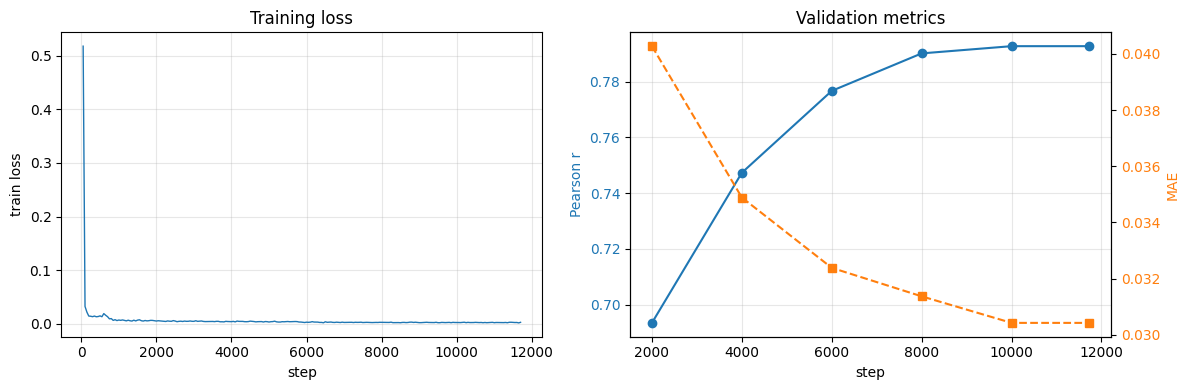

In [133]:
# Cell 16 [Python] 可选：画 loss / eval 指标曲线（matplotlib）

import json
from pathlib import Path
import matplotlib.pyplot as plt

jsonl = Path("/home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/metrics.jsonl")
if not jsonl.exists():
    print("metrics.jsonl not found yet")
else:
    rows = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]
    log_rows  = [r for r in rows if r["kind"] == "log" and "loss" in r]
    eval_rows = [r for r in rows if r["kind"] == "eval"]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # train loss
    if log_rows:
        steps  = [r["step"] for r in log_rows]
        losses = [r["loss"] for r in log_rows]
        axs[0].plot(steps, losses, lw=1.0)
        axs[0].set_xlabel("step"); axs[0].set_ylabel("train loss")
        axs[0].set_title("Training loss")
        axs[0].grid(alpha=0.3)

    # eval pearson r
    if eval_rows:
        def pick(r, k): return r.get(k, r.get("eval_" + k))
        steps  = [r["step"] for r in eval_rows]
        pears  = [pick(r, "pearson_r") for r in eval_rows]
        maes   = [pick(r, "mae") for r in eval_rows]
        ax2 = axs[1]
        ax2.plot(steps, pears, "o-", color="tab:blue", label="Pearson r")
        ax2.set_xlabel("step"); ax2.set_ylabel("Pearson r", color="tab:blue")
        ax2.tick_params(axis="y", labelcolor="tab:blue")
        ax2b = ax2.twinx()
        ax2b.plot(steps, maes, "s--", color="tab:orange", label="MAE")
        ax2b.set_ylabel("MAE", color="tab:orange")
        ax2b.tick_params(axis="y", labelcolor="tab:orange")
        ax2.set_title("Validation metrics")
        ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 5 训练完成 + 评测 + 输出

In [134]:
# Cell 17 [Python] 等训练完成，读 training_metrics.json

import json, time
from pathlib import Path

p = Path("/home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/training_metrics.json")

while not p.exists():
    print("Waiting for training to finish ...", time.strftime("%H:%M:%S"))
    time.sleep(60)

m = json.loads(p.read_text())
print(json.dumps(m, indent=2))

v = m.get("validation_metrics", {})
def pick(k, default=None):
    return v.get(k, v.get("eval_" + k, default))

print("\n-- Training summary --")
print(f"  Base model        : {m['base_model']}")
print(f"  Params            : {m['n_params_million']} M")
print(f"  Train rows        : {m['train_rows']}")
print(f"  Valid rows        : {m['valid_rows']}")
print(f"  Epochs            : {m['epochs']}")
print(f"  Effective batch   : {m['effective_batch_size']}")
print(f"  Max seq len       : {m['max_seq_length']}")
print(f"  Precision         : bf16={m.get('bf16', False)}, fp16={m.get('fp16', False)}")
print(f"  Train runtime min : {m['train_runtime_sec']/60:.1f}")

print("\n-- Validation metrics --")
for k in ["mae", "mse", "rmse", "pearson_r", "spearman_rho"]:
    val = pick(k)
    if val is not None:
        print(f"  {k:15s} : {val:.6f}")

{
  "framework": "paddlepaddle + paddlenlp",
  "base_model": "/home/aistudio/work/cleantest-agent/.ms_cache/Qwen/Qwen2___5-Coder-0___5B",
  "n_params_million": 494.0,
  "train_rows": 375338,
  "valid_rows": 46915,
  "epochs": 2,
  "effective_batch_size": 64,
  "max_seq_length": 512,
  "learning_rate": 3e-05,
  "lr_scheduler_type": "cosine",
  "fp16": false,
  "bf16": true,
  "train_subsample": 1.0,
  "train_runtime_sec": 11951.3,
  "validation_metrics": {
    "eval_loss": 0.0036531530786305666,
    "eval_mae": 0.03042138861795675,
    "eval_mse": 0.0036531533318128434,
    "eval_rmse": 0.060441321393669444,
    "eval_pearson_r": 0.7927426750243226,
    "eval_spearman_rho": 0.8476835071211535,
    "eval_runtime": 261.0893,
    "eval_samples_per_second": 179.6895,
    "eval_steps_per_second": 2.8113,
    "progress_or_epoch": 2.0
  }
}

-- Training summary --
  Base model        : /home/aistudio/work/cleantest-agent/.ms_cache/Qwen/Qwen2___5-Coder-0___5B
  Params            : 494.0 M
  Tra

In [135]:
# Cell 19 [Python] 测试集评测

import sys, subprocess
from pathlib import Path

repo = Path("/home/aistudio/work/cleantest-agent")
run_dir = repo / "experiments/results/coverage_run"
max_len_file = run_dir / "MAX_LEN_DECIDED"
max_len = int(max_len_file.read_text().strip()) if max_len_file.exists() else 512

all_eval = list(repo.rglob("evaluate_model.py"))
eval_py = next((p for p in all_eval if "paddle" in str(p)), all_eval[0])
print("Using:", eval_py)

subprocess.check_call(
    [sys.executable, str(eval_py),
     "--input_csv",  str(run_dir / "splits/test.csv"),
     "--model_path", str(run_dir / "qwen_0p5b_a800"),
     "--output_predictions", str(run_dir / "test_pred_a800.csv"),
     "--batch_size", "128",
     "--max_seq_length", str(max_len),
     "--threshold", "0.01"],
    cwd=str(repo),
)

print("\n-- test_metrics.json --")
print((run_dir / "test_metrics.json").read_text())

Using: /home/aistudio/work/cleantest-agent/skills/cleantest-coverage-filter/scripts_paddle/evaluate_model.py


/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/opt/conda/envs/pure-paddle/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package o

file: /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/model_state.pdparams is paddle weight.


[2026-05-24 05:10:00,661] [    INFO] - Loaded weights file from disk, setting weights to model.
W0524 05:10:00.840965 397956 gpu_resources.cc:116] Please NOTE: device: 0, GPU Compute Capability: 8.0, Driver API Version: 12.8, Runtime API Version: 12.6
[2026-05-24 05:10:03,147] [    INFO] - All model checkpoint weights were used when initializing Qwen2ForSequenceClassification.

[2026-05-24 05:10:03,147] [    INFO] - All the weights of Qwen2ForSequenceClassification were initialized from the model checkpoint at /home/aistudio/work/cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Qwen2ForSequenceClassification for predictions without further training.
[2026-05-24 05:10:03,194] [   ERROR] - Using sep_token, but it is not set yet.
W0524 05:10:03.489745 397956 multiply_fwd_func.cc:86] got different data type, run type promotion automatically, this may cause data type been chan

{
  "n": 46921,
  "mae": 0.030912795437683854,
  "mse": 0.00393898547312877,
  "rmse": 0.06276133740710733,
  "r2": 0.6040523796178323,
  "pearson_r": 0.7780072209897502,
  "spearman_rho": 0.8481237980305599,
  "threshold": 0.01,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "confusion": {
    "tp": 0,
    "fp": 7,
    "fn": 0,
    "tn": 46914
  }
}

-- test_metrics.json --
{
  "n": 46921,
  "mae": 0.030912795437683854,
  "mse": 0.00393898547312877,
  "rmse": 0.06276133740710733,
  "r2": 0.6040523796178323,
  "pearson_r": 0.7780072209897502,
  "spearman_rho": 0.8481237980305599,
  "threshold": 0.01,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "confusion": {
    "tp": 0,
    "fp": 7,
    "fn": 0,
    "tn": 46914
  }
}


In [136]:
# Cell 21 [Python] 9 项指标 + 自动生成 LaTeX 表格片段

import json
from pathlib import Path

m = json.loads(
    (Path("/home/aistudio/work/cleantest-agent/experiments/results/coverage_run/test_metrics.json")
     ).read_text()
)

print("-" * 60)
print("Filter 3 (Qwen2.5-Coder-0.5B) test set performance")
print("-" * 60)
print(f"  Test set size       : {m['n']:>12,}")
print("\n  Regression")
print(f"  MAE                 : {m['mae']:.4f}")
print(f"  MSE                 : {m['mse']:.4f}")
print(f"  RMSE                : {m['rmse']:.4f}")
print(f"  R^2                 : {m['r2']:.4f}")
print(f"  Pearson r           : {m['pearson_r']:.4f}")
print(f"  Spearman rho        : {m['spearman_rho']:.4f}")
print(f"\n  Classification (threshold = {m['threshold']})")
print(f"  Precision           : {m['precision']:.4f}")
print(f"  Recall              : {m['recall']:.4f}")
print(f"  F1                  : {m['f1']:.4f}")
print("\n  Confusion")
c = m['confusion']
print(f"  TP={c['tp']:>6,}  FP={c['fp']:>6,}  FN={c['fn']:>6,}  TN={c['tn']:>6,}")

print("\n" + "-" * 60)
print("LaTeX snippet for Table tab:filter3-model-mode")
print("-" * 60)
print(rf"""\begin{{tabular}}{{lr}}
\toprule
\textbf{{Metric}} & \textbf{{Value}} \\
\midrule
\multicolumn{{2}}{{l}}{{\emph{{Regression on continuous coverage}}}} \\
\quad MAE                              & {m['mae']:.4f}        \\
\quad MSE                              & {m['mse']:.4f}        \\
\quad RMSE                             & {m['rmse']:.4f}       \\
\quad $R^2$                            & {m['r2']:.4f}         \\
\quad Pearson $r$                      & {m['pearson_r']:.4f}  \\
\quad Spearman $\rho$                  & {m['spearman_rho']:.4f} \\
\midrule
\multicolumn{{2}}{{l}}{{\emph{{Threshold-aware classification ($\tau = 0.01$)}}}} \\
\quad Precision                        & {m['precision']:.4f}  \\
\quad Recall                           & {m['recall']:.4f}     \\
\quad F1                               & {m['f1']:.4f}         \\
\bottomrule
\end{{tabular}}""")

------------------------------------------------------------
Filter 3 (Qwen2.5-Coder-0.5B) test set performance
------------------------------------------------------------
  Test set size       :       46,921

  Regression
  MAE                 : 0.0309
  MSE                 : 0.0039
  RMSE                : 0.0628
  R^2                 : 0.6041
  Pearson r           : 0.7780
  Spearman rho        : 0.8481

  Classification (threshold = 0.01)
  Precision           : 0.0000
  Recall              : 0.0000
  F1                  : 0.0000

  Confusion
  TP=     0  FP=     7  FN=     0  TN=46,914

------------------------------------------------------------
LaTeX snippet for Table tab:filter3-model-mode
------------------------------------------------------------
\begin{tabular}{lr}
\toprule
\textbf{Metric} & \textbf{Value} \\
\midrule
\multicolumn{2}{l}{\emph{Regression on continuous coverage}} \\
\quad MAE                              & 0.0309        \\
\quad MSE                           

---
## 6 实验小结

### 训练完成后回本地的待办

把这 5 个文件下载到本地仓库：

```
/home/aistudio/work/cleantest-agent/experiments/results/coverage_run/
  test_metrics.json                              -> cleantest-agent/experiments/results/coverage_run/test_metrics.json
  train_a800.log                                 -> cleantest-agent/experiments/results/coverage_run/train_a800.log
  test_pred_a800.csv                             -> cleantest-agent/experiments/results/coverage_run/test_pred_a800.csv
  qwen_0p5b_a800/training_metrics.json           -> cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/training_metrics.json
  qwen_0p5b_a800/metrics.jsonl                   -> cleantest-agent/experiments/results/coverage_run/qwen_0p5b_a800/metrics.jsonl
```